Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0

# BUS-BRA Breast Ultrasound — Data Quality Snapshot

Before building any segmentation pipeline, we profile the dataset. This notebook is a **read-only diagnostic pass**: it does not train anything.

The checks are split into two tiers:

- **Part A — Core checks (gating).** The four checks that decide whether and how the segmentation pipeline is built: file integrity, format uniformity, **class balance**, and image geometry.
- **Part B — Extended profiling (optional).** Composition (benign/malignant, BI-RADS, histology, device), predefined CV folds, intensity detail, connected-component analysis, and a visual spot-check. Useful for later (stratified evaluation, domain-shift analysis).

**Target task (downstream):** Binary tumor segmentation (tumor vs. background)  
**Modality:** Breast Ultrasound (B-mode)  
**Dataset:** [BUS-BRA](https://www.kaggle.com/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/data)  
**Author:** Lakshmi Mahabaleshwara 

## Audience and prerequisites

Written for **ML practitioners new to MONAI** and **beginners learning medical segmentation**. Assumes Python fluency; explains data-profiling concepts as they come up.

## About the data

BUS-BRA contains **1875 B-mode breast ultrasound images from 1064 patients**, acquired on four ultrasound scanners at the National Institute of Cancer (Rio de Janeiro, Brazil). Each image has a biopsy-proven label (benign/malignant), a BI-RADS category (2–5), a histology string, and a binary tumor segmentation mask. The CSV also ships **predefined cross-validation folds** (5-fold and 10-fold) and hold-out partitions.

## 1. Environment detection

### §1.1 — Detecting which platform we're on

**What this cell does:** Detects whether we are on Kaggle, Colab, or local

**Why:** The dataset path differs by platform. On Kaggle the data lands under `/kaggle/input/...`. Centralizing detection keeps every downstream path reference clean.

In [1]:
import os
import sys
from pathlib import Path


def detect_environment() -> str:
    """Return one of 'kaggle', 'colab', 'local'."""
    if os.path.exists("/kaggle/input"):
        return "kaggle"
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        pass
    return "local"


ENV = detect_environment()
print(f"Detected environment: {ENV}")

Detected environment: kaggle


### §1.2 — Installing dependencies

**What this cell does:** Installs the few libraries this snapshot needs. Everything here ships by default on Kaggle, so the install is usually a no-op — but it makes the notebook self-contained on Colab/local too.

**Why:** A data-quality pass needs only `pandas`, `numpy`, `Pillow`, `matplotlib`, and `scipy` (for connected-component analysis of masks).

> On Kaggle, enable **Internet** in the notebook settings (right sidebar) if any install is needed.

In [9]:
# These all ship on Kaggle by default; install is a safety net for Colab/local.
# kagglehub is used by the §3.1 fallback to self-download the dataset.
%pip install -q pandas numpy pillow matplotlib scipy kagglehub 2>/dev/null

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

print("numpy", np.__version__, "| pandas", pd.__version__)

Note: you may need to restart the kernel to use updated packages.
numpy 2.4.6 | pandas 2.3.3


## 2. Config

### §2.1 — Defining the config

**What this cell does:** Declares a single `SnapshotConfig` dataclass holding paths and a couple of sampling knobs. 

**Why:** `full_scan` lets you profile all 1875 pairs (fast, ~6 s) or a quick sample while iterating. `multiblob_sample` caps the (slightly slower) connected-component analysis.

In [10]:
from dataclasses import dataclass
from typing import Optional


@dataclass
class SnapshotConfig:
    data_root: Optional[Path] = None   # Resolved in §3
    images_dirname: str = "Images"
    masks_dirname: str = "Masks"
    csv_name: str = "bus_data.csv"
    full_scan: bool = True             # True = all 1875 pairs; False = sample
    scan_sample: int = 400             # Used when full_scan = False
    multiblob_sample: int = 400        # How many masks to check for >1 component
    random_state: int = 0


cfg = SnapshotConfig()
print(cfg)

SnapshotConfig(data_root=None, images_dirname='Images', masks_dirname='Masks', csv_name='bus_data.csv', full_scan=True, scan_sample=400, multiblob_sample=400, random_state=0)


## 3. Dataset access

### §3.1 — Resolving the dataset path

**What this cell does:** Locates the canonical data folder — the one containing `Images/`, `Masks/`, and `bus_data.csv`. It first searches local/attached paths (case-insensitively), and if nothing is found, **falls back to downloading the dataset directly via `kagglehub`**.

**Why:** The `orvile` Kaggle re-upload may nest folders differently than the original, so we match folder names case-insensitively rather than hard-coding a path. The kagglehub fallback means the notebook is self-contained: you don't have to manually attach the dataset.

> **⚠️ Enable Internet first.** The kagglehub download requires internet access. On Kaggle, open the right sidebar → **Settings** → toggle **Internet on** (you may need a phone-verified account). Without it, the download step will fail.

In [11]:
def _dir_has(path: Path, name: str) -> bool:
    """Case-insensitive check for a child entry."""
    if not path.is_dir():
        return False
    lname = name.lower()
    return any(c.name.lower() == lname for c in path.iterdir())


def _looks_like_data_root(path: Path) -> bool:
    """A valid root has Images/, Masks/, and the CSV (case-insensitive)."""
    return (
        _dir_has(path, cfg.images_dirname)
        and _dir_has(path, cfg.masks_dirname)
        and _dir_has(path, cfg.csv_name)
    )


def _resolve_child(path: Path, name: str) -> Path:
    """Return the actual child path matching `name` case-insensitively."""
    lname = name.lower()
    for c in path.iterdir():
        if c.name.lower() == lname:
            return c
    return path / name  # fallback


def _search_for_root(base: Path) -> Optional[Path]:
    """Scan base and all its subdirectories for a valid data root."""
    if not base.exists():
        return None
    for candidate in [base] + [p for p in base.rglob("*") if p.is_dir()]:
        if _looks_like_data_root(candidate):
            return candidate
    return None


def resolve_data_root() -> Path:
    # 1) Look in attached/local locations first.
    search_base = Path("/kaggle/input") if ENV == "kaggle" else Path(".")
    found = _search_for_root(search_base)
    if found is not None:
        print(f"Found dataset locally at: {found}")
        return found

    # 2) Fallback: download via kagglehub (needs Internet enabled).
    print("Not found locally. Attempting kagglehub download...")
    try:
        import kagglehub
    except ImportError as e:
        raise RuntimeError(
            "kagglehub not installed and dataset not found locally. "
            "Either attach the BUS-BRA dataset via 'Add Input', or "
            "install kagglehub (pip install kagglehub) with Internet enabled."
        ) from e

    downloaded = Path(kagglehub.dataset_download(
        "orvile/bus-bra-a-breast-ultrasound-dataset"))
    found = _search_for_root(downloaded)
    if found is not None:
        print(f"Downloaded to: {found}")
        return found
    raise FileNotFoundError(
        f"Downloaded to {downloaded} but could not locate a folder "
        f"containing Images/, Masks/, and {cfg.csv_name} inside it. "
        "Inspect the printed path and adjust cfg if the layout differs."
    )


cfg.data_root = resolve_data_root()
IMAGES = _resolve_child(cfg.data_root, cfg.images_dirname)
MASKS = _resolve_child(cfg.data_root, cfg.masks_dirname)
print("Data root:", cfg.data_root)
print("Images dir:", IMAGES)
print("Masks dir :", MASKS)

Not found locally. Attempting kagglehub download...
Downloaded to: /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA
Data root: /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA
Images dir: /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA/Images
Masks dir : /kaggle/input/datasets/orvile/bus-bra-a-breast-ultrasound-dataset/BUSBRA/BUSBRA/Masks


# Part A — Core checks (gating)

These four checks determine whether the dataset is usable and how the segmentation pipeline must be built.  

1. Integrity check (does the data even line up?)
2. Format check (are the assumptions about pixels true?)
3. Pixel sweep that powers the class balance
4. Geometry checks.


## A.1 — File integrity (gate)

**What this cell does:** Reads `bus_data.csv` (one row per image, keyed by `ID` like `bus_0001-l`), derives each mask path (`mask_0001-l.png`), and verifies every image and mask file actually exists on disk.

**Why this is core:** If images, masks, and CSV rows do not line up 1:1:1, nothing downstream works. A clean result here means no orphaned images or masks.

In [26]:
df = pd.read_csv(cfg.data_root / cfg.csv_name)

def image_path(image_id: str) -> Path:
    return IMAGES / f"{image_id}.png"

def mask_path(image_id: str) -> Path:
    # 'bus_0001-l' -> 'mask_0001-l'
    suffix = image_id.split("bus_")[1]
    return MASKS / f"mask_{suffix}.png"

df["image_path"] = df["ID"].map(image_path)
df["mask_path"] = df["ID"].map(mask_path)
df["image_exists"] = df["image_path"].map(lambda p: p.is_file())
df["mask_exists"] = df["mask_path"].map(lambda p: p.is_file())

manifest = df
print(f"Rows in CSV          : {len(manifest)}")
print(f"Images on disk       : {len(list(IMAGES.glob('*.png')))}")
print(f"Masks on disk        : {len(list(MASKS.glob('*.png')))}")
print(f"Missing image files  : {(~manifest.image_exists).sum()}")
print(f"Missing mask files   : {(~manifest.mask_exists).sum()}")

Rows in CSV          : 1875
Images on disk       : 1875
Masks on disk        : 1875
Missing image files  : 0
Missing mask files   : 0


## A.2 — Format uniformity + pixel sweep (gate)

**What this cell does:** It opens every image/mask pair once and records: colour mode, dimensions, intensity stats, tumor pixel count, tumor area fraction, and whether the mask is empty. Results are cached in `pixel_stats` so every later check is from the cached dataframe operation.

**Why this is core:** It verifies the two format assumptions the pipeline depends on — images are single-channel grayscale (`L`), masks are binary (`1`) — and produces the numbers the class-balance and geometry gates need. If images were RGB or masks were multi-valued, the transform pipeline would need rewriting.

In [27]:
rows = manifest if cfg.full_scan else manifest.sample(
    cfg.scan_sample, random_state=cfg.random_state)

modes_img, modes_mask = set(), set()
records = []
for r in rows.itertuples():
    im_pil = Image.open(r.image_path)
    mk_pil = Image.open(r.mask_path)
    modes_img.add(im_pil.mode)
    modes_mask.add(mk_pil.mode)
    im = np.asarray(im_pil)
    mk = np.asarray(mk_pil)
    if im.ndim == 3:               # collapse to single channel if RGB-stored
        im = im[..., 0]
    mk = (mk > 0).astype(np.uint8)  # force binary
    H, W = im.shape
    tumor_px = int(mk.sum())
    records.append(dict(
        ID=r.ID, H=H, W=W, npix=H * W,
        img_mean=float(im.mean()), img_std=float(im.std()),
        img_min=int(im.min()), img_max=int(im.max()),
        tumor_px=tumor_px, tumor_frac=tumor_px / (H * W),
        mask_empty=(tumor_px == 0),
    ))

pixel_stats = pd.DataFrame(records)
print(f"Scanned {len(pixel_stats)} pairs")
print("Image colour modes seen :", modes_img, "(L = 8-bit grayscale)")
print("Mask  colour modes seen :", modes_mask, "(1 = 1-bit binary)")

Scanned 1875 pairs
Image colour modes seen : {'L'} (L = 8-bit grayscale)
Mask  colour modes seen : {'1'} (1 = 1-bit binary)


## A.3 — Class balance

**What this cell does:** Reports the foreground (tumor) vs. background balance in three ways: empty-mask count, per-image tumor-area distribution, and the global background: foreground ratio.

**Why this is THE check:** This result decides the loss function and predicts the main failure mode. Tumors occupy a small fraction of each image, so the background class dominates. A naive pixel-wise loss will collapse to predicting all background.

Empty masks (no tumor pixels): 0

Tumor area as % of image:
count    1875.000
mean        8.660
std         7.554
min         0.609
25%         3.301
50%         6.218
75%        11.808
max        57.539
Name: tumor_frac, dtype: float64

Foreground (tumor) : 8.62%
Background         : 91.38%
Background : foreground ratio = 10.6 : 1


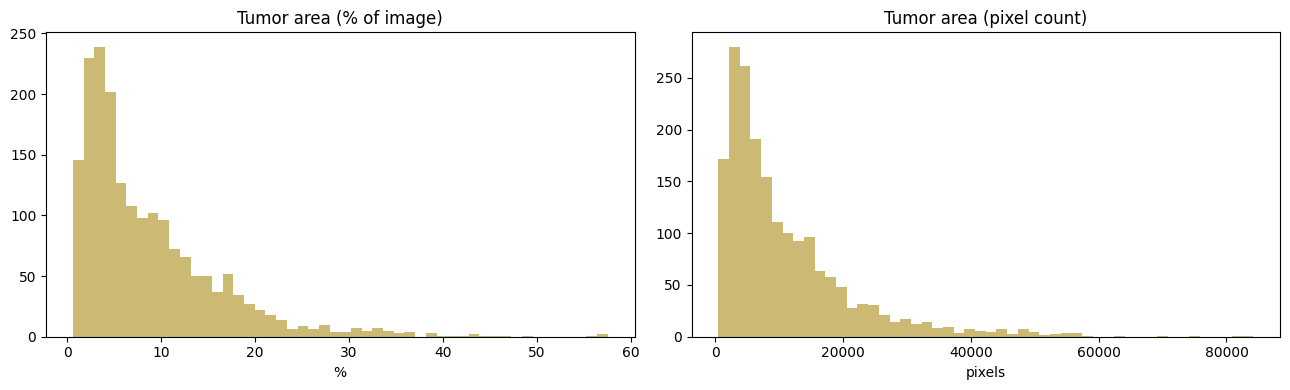

In [28]:
# --- empty masks: would need special handling/exclusion in the loss ---
n_empty = int(pixel_stats["mask_empty"].sum())
print(f"Empty masks (no tumor pixels): {n_empty}")

# --- per-image tumor area as % of image ---
print("\nTumor area as % of image:")
print((pixel_stats["tumor_frac"] * 100).describe().round(3))

# --- global foreground/background balance: drives the loss choice ---
fg = int(pixel_stats["tumor_px"].sum())
tot = int(pixel_stats["npix"].sum())
print(f"\nForeground (tumor) : {fg/tot*100:.2f}%")
print(f"Background         : {(tot-fg)/tot*100:.2f}%")
print(f"Background : foreground ratio = {(tot-fg)/fg:.1f} : 1")

# --- plot the distribution so the imbalance is visible ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(pixel_stats["tumor_frac"] * 100, bins=50, color="#ccb974")
ax[0].set_title("Tumor area (% of image)"); ax[0].set_xlabel("%")
ax[1].hist(pixel_stats["tumor_px"], bins=50, color="#ccb974")
ax[1].set_title("Tumor area (pixel count)"); ax[1].set_xlabel("pixels")
plt.tight_layout(); plt.show()

## A.4 — Image geometry

**What this cell does:** Profiles image width/height: how many distinct resolutions exist, the dimension ranges, and the aspect-ratio distribution.

**Why this is core:** Many distinct resolutions mean resizing to a fixed square is **mandatory**; the aspect-ratio spread tells you how much distortion a naive square resize introduces, and whether to consider padding instead.

Distinct (W, H) resolutions: 713

Width : {'count': 1875.0, 'mean': 321.3, 'std': 76.9, 'min': 240.0, '25%': 276.0, '50%': 286.0, '75%': 323.0, 'max': 579.0}
Height: {'count': 1875.0, 'mean': 391.3, 'std': 52.9, 'min': 268.0, '25%': 350.0, '50%': 383.0, '75%': 435.0, 'max': 478.0}

Aspect ratio (H/W): {'count': 1875.0, 'mean': 1.247, 'std': 0.173, 'min': 0.473, '25%': 1.199, '50%': 1.309, '75%': 1.354, 'max': 1.569}


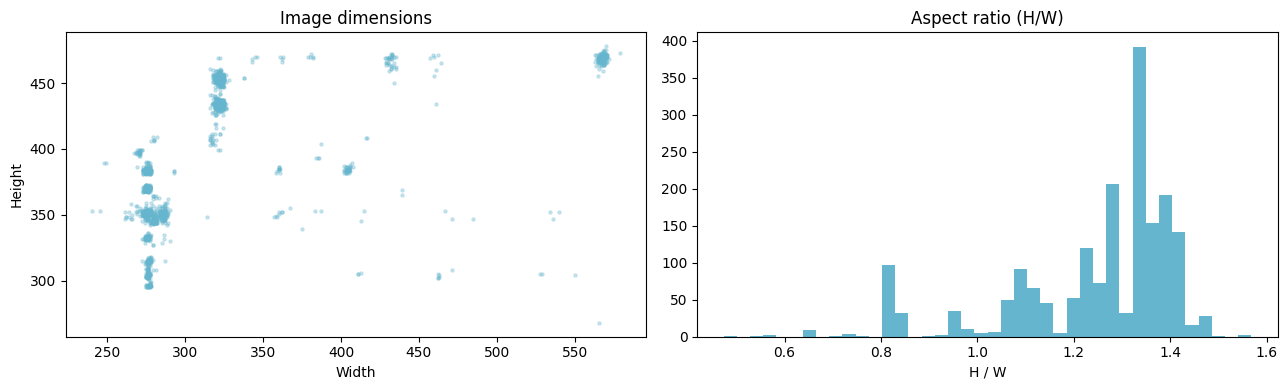

In [29]:
n_res = pixel_stats.groupby(["W", "H"]).ngroups
ar = pixel_stats["H"] / pixel_stats["W"]
print(f"Distinct (W, H) resolutions: {n_res}")
print()
print("Width :", pixel_stats["W"].describe().round(1).to_dict())
print("Height:", pixel_stats["H"].describe().round(1).to_dict())
print()
print("Aspect ratio (H/W):", ar.describe().round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(pixel_stats["W"], pixel_stats["H"], s=5, alpha=0.3, color="#64b5cd")
ax[0].set_title("Image dimensions"); ax[0].set_xlabel("Width"); ax[0].set_ylabel("Height")
ax[1].hist(ar, bins=40, color="#64b5cd")
ax[1].set_title("Aspect ratio (H/W)"); ax[1].set_xlabel("H / W")
plt.tight_layout(); plt.show()

# Part B — Extended profiling (optional)

## B.1 — Manifest schema

**What this cell does:** Prints the columns and a couple of sample rows so you can see exactly what metadata is available.

**Why:** Knowing the columns tells you what stratification and grouping are possible later. `Case` is the patient ID; `K5B/K10B/K5P/K10P` are predefined folds; `BBOX` gives lesion bounding boxes.

In [30]:
print("Columns:", list(manifest.columns))
print()
manifest.head(2).T

Columns: ['ID', 'Case', 'Histology', 'Pathology', 'BIRADS', 'Device', 'Width', 'Height', 'Side', 'HOB', 'K5B', 'K10B', 'HOP', 'K5P', 'K10P', 'BBOX', 'image_path', 'mask_path', 'image_exists', 'mask_exists']



,0,1
ID,bus_0001-l,bus_0001-r
Case,1,1
Histology,invasive ductal carcinoma,invasive ductal carcinoma
Pathology,malignant,malignant
BIRADS,4,4
Device,GE Logiq 7 @10-14MHz,GE Logiq 7 @10-14MHz
Width,274,275
Height,353,353
Side,left,right
HOB,2,2


## B.2 — Counts, patients, and label balance

**What this cell does:** Total images, unique patients, images-per-patient, and the benign/malignant split.

**Why:** Frames the dataset. The patient-vs-image count confirms whether subject-grouped splitting is needed (it is — patients contribute paired left/right views). The benign/malignant ratio is useful for stratified evaluation, not for the segmentation loss.

In [31]:
n_images = len(manifest)
n_patients = manifest["Case"].nunique()
per_patient = manifest["Case"].value_counts()

print(f"Total images        : {n_images}")
print(f"Unique patients     : {n_patients}")
print(f"Images per patient  : mean {per_patient.mean():.2f}, "
      f"min {per_patient.min()}, max {per_patient.max()}")
print()
print("Pathology balance:")
print(manifest["Pathology"].value_counts())
print()
print("As fraction:")
print((manifest["Pathology"].value_counts(normalize=True) * 100).round(1))

Total images        : 1875
Unique patients     : 1064
Images per patient  : mean 1.76, min 1, max 2

Pathology balance:
Pathology
benign       1268
malignant     607
Name: count, dtype: int64

As fraction:
Pathology
benign       67.6
malignant    32.4
Name: proportion, dtype: float64


## B.3 — BI-RADS, histology, device, and side

**What this cell does:** Breaks down the categorical metadata: BI-RADS category, histology diagnosis, acquisition device, and imaged side.

**Why:** BI-RADS and histology describe *what kinds of lesions* the model will see. Device mix flags a potential domain-shift axis (different scanners produce different speckle/contrast). Side (`left`/`right`/`single`) explains the per-patient image counts.

In [32]:
for col in ["BIRADS", "Side", "Device"]:
    print(f"=== {col} ===")
    print(manifest[col].value_counts().sort_index() if col == "BIRADS"
          else manifest[col].value_counts())
    print()

print("=== Histology (top 10) ===")
print(manifest["Histology"].value_counts().head(10))

=== BIRADS ===
BIRADS
2    562
3    463
4    693
5    157
Name: count, dtype: int64

=== Side ===
Side
left      811
right     811
single    253
Name: count, dtype: int64

=== Device ===
Device
GE Logiq 7 @10-14MHz            902
GE Logiq 5 @10-12MHz            809
Toshiba Aplio 300 @12-14 MHz    139
U-Systems @10-14MHz              25
Name: count, dtype: int64

=== Histology (top 10) ===
Histology
fibroadenoma                  835
invasive ductal carcinoma     520
cyst                          142
fibrocystic changes           106
invasive lobular carcinoma     42
intraductal papilloma          41
sclerosing adenosis            37
hyperplasia                    31
lipoma                         17
phyllodes tumor                13
Name: count, dtype: int64


## B.4 — Predefined cross-validation folds

**What this cell does:** Confirms the CSV ships ready-made fold assignments — `K5B`/`K10B` (5- and 10-fold) and `K5P`/`K10P` (patient-grouped), plus `HOB`/`HOP` hold-out flags.

**Why:** Lets you adopt the datasets authors' patient-grouped folds instead of constructing leakage-free splits ourself

In [35]:
fold_cols = ["HOB", "HOP", "K5B", "K10B", "K5P", "K10P"]
for c in fold_cols:
    vals = sorted(manifest[c].unique())
    print(f"{c:6s}: {len(vals)} groups -> {vals}")
print()
print("Example K5P fold sizes (patient-grouped 5-fold):")
print(manifest["K5P"].value_counts().sort_index())

HOB   : 2 groups -> [np.int64(1), np.int64(2)]
HOP   : 2 groups -> [np.int64(1), np.int64(2)]
K5B   : 5 groups -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
K10B  : 10 groups -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
K5P   : 5 groups -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
K10P  : 10 groups -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Example K5P fold sizes (patient-grouped 5-fold):
K5P
1    376
2    385
3    366
4    365
5    383
Name: count, dtype: int64


## B.5 — Composition diagnostic plots

**What this cell does:** Renders the categorical composition as bar charts: pathology, BI-RADS, and device.

**Why:** A picture makes the imbalance obvious at a glance — benign cases outnumber malignant roughly 2:1, BI-RADS 4 dominates, and two GE scanners account for most acquisitions.

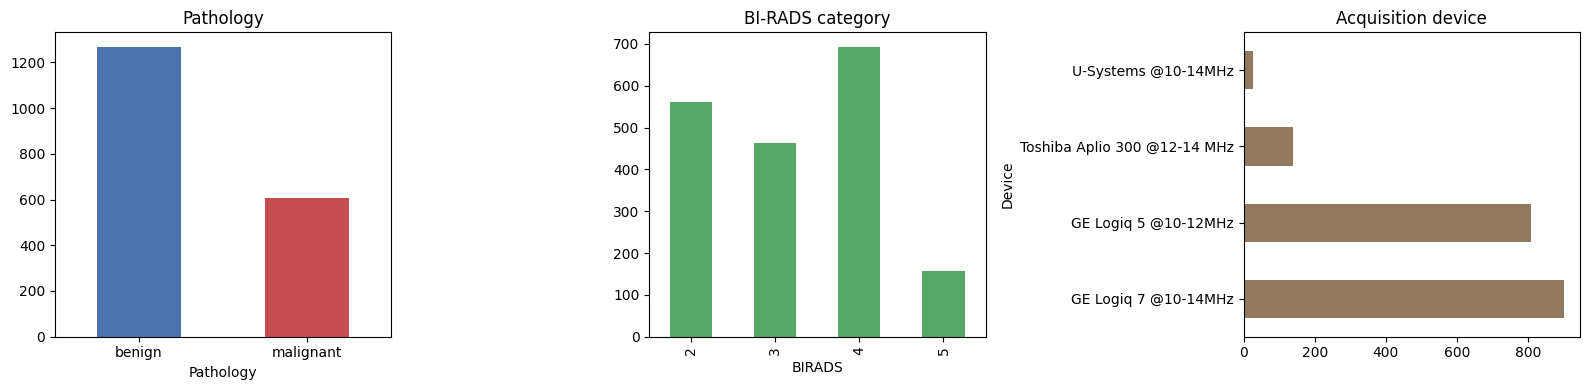

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
manifest["Pathology"].value_counts().plot.bar(
    ax=ax[0], color=["#4c72b0", "#c44e52"]); ax[0].set_title("Pathology")
ax[0].tick_params(axis="x", rotation=0)
manifest["BIRADS"].value_counts().sort_index().plot.bar(
    ax=ax[1], color="#55a868"); ax[1].set_title("BI-RADS category")
manifest["Device"].value_counts().plot.barh(
    ax=ax[2], color="#937860"); ax[2].set_title("Acquisition device")
plt.tight_layout(); plt.show()

## B.6 — Intensity distribution

**What this cell does:** Summarizes per-image intensity statistics and plots the distribution of per-image mean brightness and standard deviation.

**Why:** A wide spread of per-image means signals that intensity normalization will help in the transform pipeline. This is a refinement on the pixel sweep already done in A.2 — useful, but the pipeline will normalize regardless.

Per-image intensity stats (0-255 scale):
       img_mean  img_std  img_min  img_max
count   1875.00  1875.00  1875.00  1875.00
mean      83.10    39.62     8.93   235.85
std       28.70    11.80    11.11    24.21
min       13.84    15.59     0.00   142.00
25%       60.38    29.32     0.00   213.00
50%       81.63    38.70     4.00   255.00
75%      103.41    48.91    15.00   255.00
max      186.46    72.22    65.00   255.00


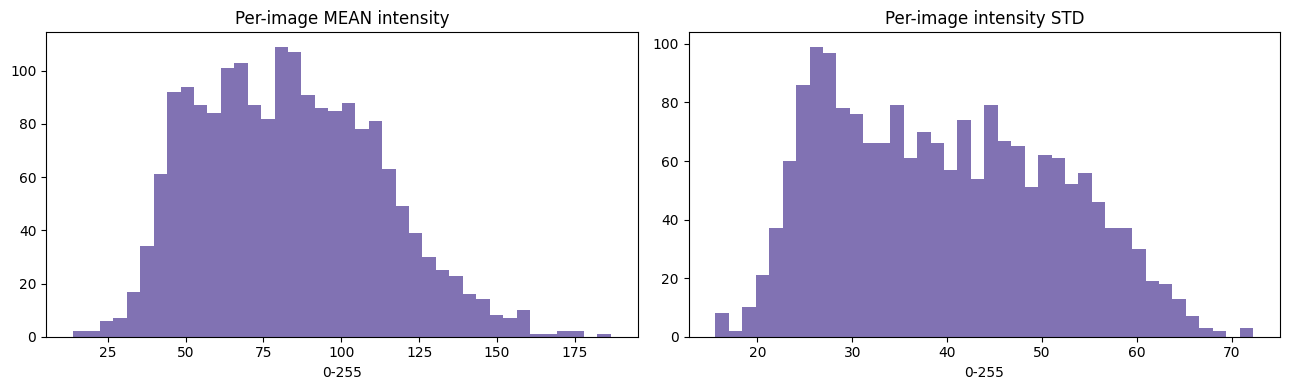

In [37]:
print("Per-image intensity stats (0-255 scale):")
print(pixel_stats[["img_mean", "img_std", "img_min", "img_max"]]
      .describe().round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(pixel_stats["img_mean"], bins=40, color="#8172b3")
ax[0].set_title("Per-image MEAN intensity"); ax[0].set_xlabel("0-255")
ax[1].hist(pixel_stats["img_std"], bins=40, color="#8172b3")
ax[1].set_title("Per-image intensity STD"); ax[1].set_xlabel("0-255")
plt.tight_layout(); plt.show()

## B.7 — Connected components (one tumor or many?)

**What this cell does:** Runs connected-component labeling on a sample of masks to count how many distinct blobs each contains.

**Why:** If every mask is a single connected region, the task is clean single-lesion segmentation. Multiple components would mean either multi-focal lesions or annotation noise, and would affect post-processing choices (e.g. keep-largest-component).

In [38]:
check = (pixel_stats if cfg.full_scan
         else pixel_stats).sample(
             min(cfg.multiblob_sample, len(pixel_stats)),
             random_state=cfg.random_state)
blob_counts = []
for image_id in check["ID"]:
    mp = mask_path(image_id)
    mk = np.asarray(Image.open(mp)) > 0
    _, n = ndimage.label(mk)
    blob_counts.append(n)

blob_series = pd.Series(blob_counts)
print(f"Masks checked: {len(blob_series)}")
print("Connected-component count per mask:")
print(blob_series.value_counts().sort_index())
print(f"\nMasks with >1 component: {(blob_series > 1).sum()}")

Masks checked: 400
Connected-component count per mask:
1    400
Name: count, dtype: int64

Masks with >1 component: 0


## B.8 — Image + mask overlays

**What this cell does:** Displays a handful of random image/mask pairs with the tumor mask overlaid in colour.

**Why:** Numbers can hide problems that the eye catches instantly — misaligned masks, masks covering the whole image, and obvious annotation errors. A visual spot-check for the sanity test.

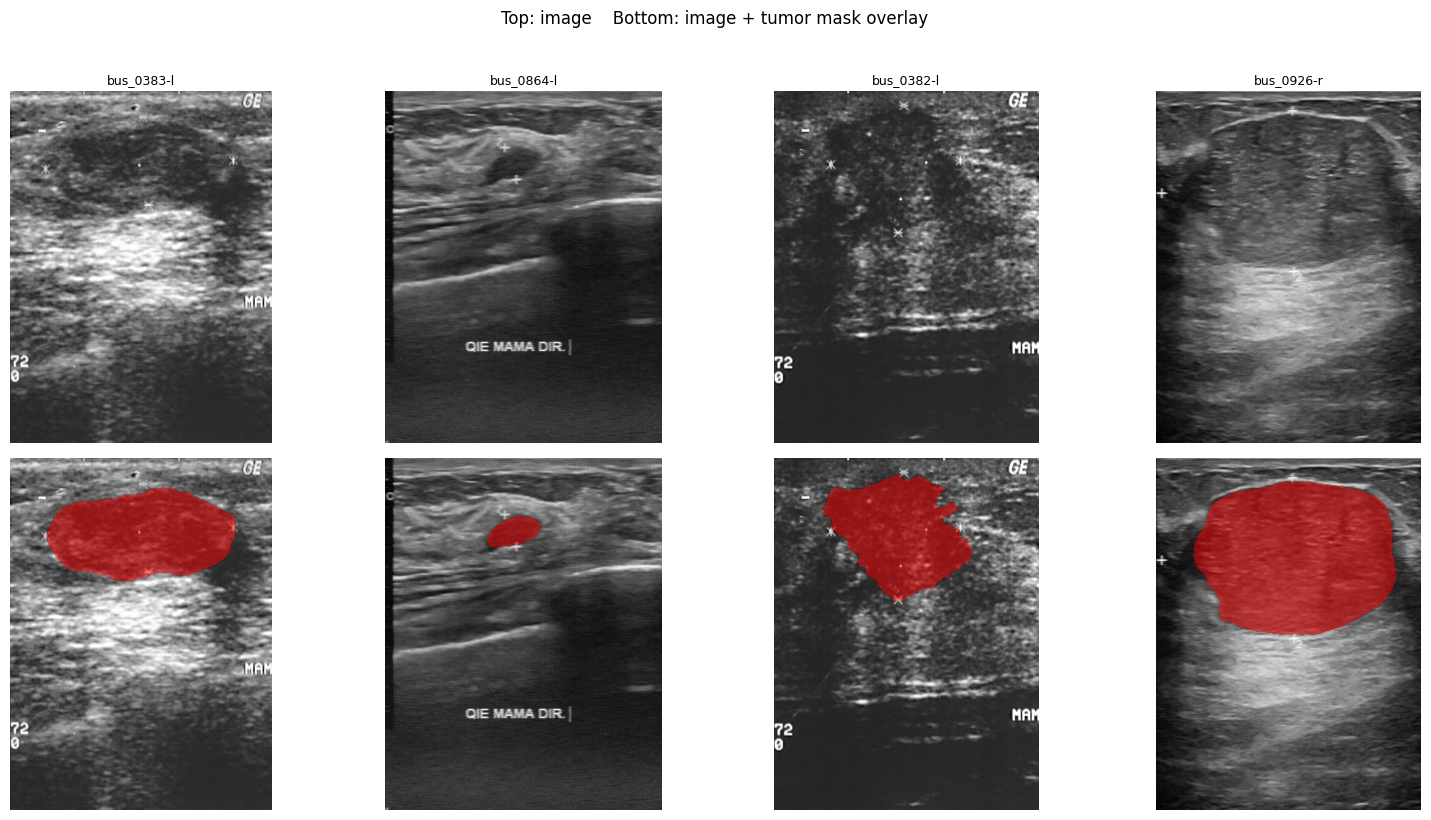

In [39]:
sample_ids = manifest.sample(4, random_state=3)["ID"].tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, image_id in enumerate(sample_ids):
    im = np.asarray(Image.open(image_path(image_id)))
    mk = np.asarray(Image.open(mask_path(image_id))) > 0
    if im.ndim == 3:
        im = im[..., 0]
    axes[0, j].imshow(im, cmap="gray")
    axes[0, j].set_title(image_id, fontsize=9); axes[0, j].axis("off")
    axes[1, j].imshow(im, cmap="gray")
    axes[1, j].imshow(np.ma.masked_where(~mk, mk), cmap="autumn", alpha=0.5)
    axes[1, j].axis("off")
axes[0, 0].set_ylabel("image")
plt.suptitle("Top: image    Bottom: image + tumor mask overlay", y=1.02)
plt.tight_layout(); plt.show()

## Summary

### Core checks (Part A)

- **Integrity.** 1875 CSV rows, 1875 images, 1875 masks, zero missing files — perfect 1:1:1 alignment.
- **Format.** Images are 8-bit grayscale (`L`); masks are 1-bit binary (`1`). Uniform, no decoding needed.
- **Class balance (the main result).** Zero empty masks. Median tumor area ~6% of the image; global background: foreground ≈ 10.6:1. → **Use `DiceCELoss`** — Dice handles this imbalance; heavy class weighting is *not* needed.
- **Geometry.** Hundreds of distinct resolutions, aspect ratios mostly ~1.0–1.4. → **Resize to a fixed square (e.g., 256×256) is mandatory.**

### Extended profiling (Part B)

- 1875 images from 1064 patients (~1.8 each, paired left/right views → subject-grouped splits needed).
- Benign:malignant ≈ 2:1; BI-RADS 4 largest; fibroadenoma and invasive ductal carcinoma dominate histology; two GE scanners cover most acquisitions.
- The CSV ships **patient-grouped predefined folds** (K5P/K10P) — reuse these for reproducible, leakage-free splits.
- Masks are single-connected-component (one clean lesion per image); intensities span the full 0–255 range with variable per-image brightness.

### Bottom line

BUS-BRA is well-curated and a single-target binary segmentation problem, with biopsy-proven labels, clean binary masks, and ready-made patient-grouped folds. It is a strong fit for the tumor-segmentation tutorial. The next notebook can move straight to building the MONAI pipeline — using `DiceCELoss`, a 256×256 resize, intensity normalization, and the K5P folds.